In [1]:
!pip install -q transformers datasets accelerate bitsandbytes sentencepiece
!pip install -q matplotlib seaborn scikit-learn nltk
!pip install -q bert-score rouge_score sentence-transformers faiss-cpu rank_bm25

In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
from bert_score import score as bert_score
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import warnings

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
try:
    dataset_notes = load_dataset("harishnair04/mtsamples", split="train")
    df_notes = dataset_notes.to_pandas()
    if 'transcription' not in df_notes.columns and 'text' in df_notes.columns:
        df_notes = df_notes.rename(columns={'text': 'transcription'})
except Exception:
    dataset_notes = load_dataset("argilla/medical-domain", split="train")
    df_notes = dataset_notes.to_pandas().rename(columns={'text': 'transcription'})

df_notes = df_notes.dropna(subset=['transcription'])
historical_notes = df_notes['transcription'].head(2000).tolist()

complex_guidelines = [
    "GUIDELINE - TOXICOLOGY: Patient on Lithium with new Thiazide diuretic (e.g., Hydrochlorothiazide). EVIDENCE-BASED PLAN: Thiazides decrease lithium clearance. Discontinue Lithium and Thiazide. Administer IV Normal Saline. Consider hemodialysis if levels > 4.0.",
    "GUIDELINE - ONCOLOGY: Lung Adenocarcinoma, EGFR exon 19 deletion positive. EVIDENCE-BASED PLAN: Avoid standard chemotherapy. Initiate targeted EGFR TKI therapy (Osimertinib).",
    "GUIDELINE - RHEUMATOLOGY: Granulomatosis with Polyangiitis (GPA/Wegener's), positive c-ANCA, saddle-nose. EVIDENCE-BASED PLAN: Induce remission with high-dose glucocorticoids and Cyclophosphamide or Rituximab.",
    "GUIDELINE - CARDIOLOGY: Wolff-Parkinson-White (WPW) syndrome presenting with Atrial Fibrillation. EVIDENCE-BASED PLAN: AV nodal blockers (Diltiazem, Verapamil, Adenosine) are CONTRAINDICATED and can cause V-Fib. Administer IV Procainamide or perform synchronized electrical cardioversion.",
    "GUIDELINE - HEMATOLOGY: Heparin-Induced Thrombocytopenia (HIT). Patient drops platelets >50% on Heparin. EVIDENCE-BASED PLAN: Immediately stop all Heparin. Initiate non-heparin anticoagulant like Argatroban or Bivalirudin. Do NOT start Warfarin until platelets recover.",
    "GUIDELINE - NEUROLOGY: Serotonin Syndrome. Patient on SSRI + MAOI presenting with clonus and hyperthermia. EVIDENCE-BASED PLAN: Discontinue serotonergic agents. Administer Cyproheptadine (serotonin antagonist) and supportive care.",
    "GUIDELINE - NEPHROLOGY: Tumor Lysis Syndrome after Burkitt lymphoma chemo. High uric acid, high K, low Ca. EVIDENCE-BASED PLAN: Administer Rasburicase and aggressive IV fluids. Monitor electrolytes closely.",
    "GUIDELINE - PULMONOLOGY: Idiopathic Pulmonary Fibrosis with honeycombing on HRCT. EVIDENCE-BASED PLAN: Initiate anti-fibrotic therapy with Nintedanib or Pirfenidone. Supportive oxygen.",
    "GUIDELINE - OBGYN: HELLP Syndrome (Hemolysis, Elevated Liver enzymes, Low Platelets) in pregnancy. EVIDENCE-BASED PLAN: Immediate delivery is the definitive treatment. Administer IV Magnesium Sulfate for seizure prophylaxis.",
    "GUIDELINE - TOXICOLOGY: Ethylene Glycol poisoning (antifreeze), calcium oxalate crystals in urine. EVIDENCE-BASED PLAN: Administer Fomepizole (alcohol dehydrogenase inhibitor). Consider hemodialysis for severe acidosis.",
    "GUIDELINE - PEDIATRICS: Kawasaki Disease. Child with prolonged fever, strawberry tongue, and risk of coronary aneurysms. EVIDENCE-BASED PLAN: Administer IVIG (Intravenous Immunoglobulin) and high-dose Aspirin immediately.",
    "GUIDELINE - DERMATOLOGY: Stevens-Johnson Syndrome (SJS) after taking Lamotrigine. EVIDENCE-BASED PLAN: Immediately discontinue Lamotrigine. Transfer to burn unit for supportive wound care and fluid management.",
    "GUIDELINE - HEPATOLOGY: Primary Biliary Cholangitis (PBC). Female with pruritus, fatigue, positive AMA antibodies. EVIDENCE-BASED PLAN: Initiate Ursodeoxycholic acid (UDCA) to slow progression.",
    "GUIDELINE - ENDOCRINOLOGY: Pheochromocytoma crisis. Episodic hypertension, headache, tachycardia. EVIDENCE-BASED PLAN: Must block alpha receptors FIRST with Phenoxybenzamine before administering any beta-blockers to prevent hypertensive crisis.",
    "GUIDELINE - NEUROLOGY: Guillain-Barré Syndrome (GBS) post-Campylobacter infection. Ascending paralysis. EVIDENCE-BASED PLAN: Monitor respiratory status (FVC). Initiate IVIG or Plasmapheresis. Do NOT use corticosteroids.",
    "GUIDELINE - HEMATOLOGY: Thrombotic Thrombocytopenic Purpura (TTP). Schistocytes, fever, neuro symptoms. EVIDENCE-BASED PLAN: Medical emergency. Initiate Plasma Exchange (PLEX) immediately. Platelet transfusions are CONTRAINDICATED.",
    "GUIDELINE - GASTROENTEROLOGY: Carcinoid Syndrome. Flushing, diarrhea, right heart valvular lesions. EVIDENCE-BASED PLAN: Administer Somatostatin analogs (Octreotide) for symptom control.",
    "GUIDELINE - ENDOCRINOLOGY: Nelson's Syndrome. Hyperpigmentation and visual field defects following bilateral adrenalectomy. EVIDENCE-BASED PLAN: Pituitary MRI to confirm macroadenoma. Transsphenoidal surgical resection or stereotactic radiosurgery.",
    "GUIDELINE - INFECTIOUS DISEASE: Cerebral Malaria (Plasmodium falciparum). Altered mental status in returning traveler. EVIDENCE-BASED PLAN: Administer IV Artesunate immediately. Do not delay for oral artemisinin combination therapies.",
    "GUIDELINE - RHEUMATOLOGY: Macrophage Activation Syndrome (MAS) complicating adult-onset Still's disease. Extremely high ferritin. EVIDENCE-BASED PLAN: High-dose IV pulse glucocorticoids. Consider Anakinra or Cyclosporine."
]

historical_notes.extend(complex_guidelines)

In [4]:
class MultiTaskBioClinicalBERT:
    def __init__(self):
        self.ner_head = pipeline("ner", model="d4data/biomedical-ner-all", aggregation_strategy="simple", device=0 if torch.cuda.is_available() else -1)
        self.diag_head = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0 if torch.cuda.is_available() else -1)
        self.categories = ["Cardiology", "Pulmonology", "Toxicology", "Oncology", "Rheumatology"]

    def predict(self, text):
        short_text = " ".join(str(text).split()[:350]) 
        ner_results = self.ner_head(short_text)
        entities = [ent['word'].lower().replace("##", "") for ent in ner_results if ent['entity_group'] in ['Disease_disorder', 'Sign_symptom', 'Clinical_drug', 'Diagnostic_procedure']]
        diag_results = self.diag_head(short_text, self.categories)
        predicted_category = diag_results['labels'][0]
        return list(set(entities)), predicted_category

multitask_engine = MultiTaskBioClinicalBERT()

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [5]:
from rank_bm25 import BM25Okapi

embedder = SentenceTransformer('NeuML/pubmedbert-base-embeddings', device=device)
knowledge_embeddings = embedder.encode(historical_notes, show_progress_bar=False)
index = faiss.IndexFlatL2(knowledge_embeddings.shape[1])
index.add(knowledge_embeddings)

tokenized_corpus = [doc.lower().split(" ") for doc in historical_notes]
bm25 = BM25Okapi(tokenized_corpus)

bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
llm_tokenizer = AutoTokenizer.from_pretrained("HuggingFaceH4/zephyr-7b-beta")
llm_model = AutoModelForCausalLM.from_pretrained("HuggingFaceH4/zephyr-7b-beta", quantization_config=bnb_config, device_map="auto")
llm_pipeline = pipeline("text-generation", model=llm_model, tokenizer=llm_tokenizer, max_new_tokens=300)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [6]:
def process_clinical_note(text):
    baseline_prompt = f"<|system|>\nYou are a Clinical AI. Provide an Assessment and Treatment Plan for the patient.\n</s>\n<|user|>\n[CLINICAL NOTE]: {text}\nProvide Assessment and Plan:\n</s>\n<|assistant|>\n"
    baseline_ans = llm_pipeline(baseline_prompt, temperature=0.1, do_sample=True)[0]['generated_text'].split("<|assistant|>")[-1].strip()

    extracted_entities, predicted_diag = multitask_engine.predict(text)
    
    query_emb = embedder.encode([text])
    distances, dense_indices = index.search(query_emb, 2)
    
    tokenized_query = text.lower().split(" ")
    sparse_scores = bm25.get_scores(tokenized_query)
    sparse_indices = np.argsort(sparse_scores)[::-1][:2]
    
    combined_indices = list(set(dense_indices[0].tolist() + sparse_indices.tolist()))
    medical_evidence = "\n\n".join([f"EVIDENCE {idx+1}: {historical_notes[i]}" for idx, i in enumerate(combined_indices)])

    draft_prompt = f"""<|system|>
You are an Expert Medical AI. Formulate an Assessment and Treatment Plan.
Carefully review the Provided Evidence. If the evidence contains a specific guideline matching the patient's rare condition or drug interaction, you MUST follow it.
</s>
<|user|>
[CLINICAL NOTE]: {text}

[RETRIEVED MEDICAL EVIDENCE]: 
{medical_evidence}

Provide the Assessment and Plan:
</s>
<|assistant|>
"""
    final_ans = llm_pipeline(draft_prompt, temperature=0.1, do_sample=True)[0]['generated_text'].split("<|assistant|>")[-1].strip()
    
    return baseline_ans, final_ans, "Hybrid Query (Full Text)", medical_evidence, extracted_entities

In [7]:
test_cases = [
    {"type": "Toxicology", "note": "Patient on Lithium stabilized for bipolar. Started Hydrochlorothiazide 5 days ago. Presents with coarse tremors, ataxia, and confusion.", "gt_entities": ["lithium", "hydrochlorothiazide", "tremors", "ataxia", "confusion"], "ground_truth": "Lithium toxicity via thiazide interaction. Discontinue Lithium and Thiazide. IV Normal Saline. Consider hemodialysis."},
    {"type": "Oncology", "note": "Asian female, never-smoker. Lung mass biopsy shows adenocarcinoma. Positive for EGFR exon 19 deletion.", "gt_entities": ["adenocarcinoma", "egfr", "exon 19 deletion"], "ground_truth": "EGFR-mutated NSCLC. Avoid standard chemo. Initiate targeted EGFR TKI therapy (Osimertinib)."},
    {"type": "Rheumatology", "note": "45-year-old male with saddle-nose deformity, hemoptysis, and positive c-ANCA (PR3) antibodies.", "gt_entities": ["saddle-nose", "hemoptysis", "c-anca"], "ground_truth": "Granulomatosis with Polyangiitis. Induce remission with high-dose glucocorticoids and Cyclophosphamide or Rituximab."},
    {"type": "Cardiology", "note": "Known Wolff-Parkinson-White (WPW) syndrome presents to ER with rapid Atrial Fibrillation.", "gt_entities": ["wolff-parkinson-white", "wpw", "atrial fibrillation"], "ground_truth": "AV nodal blockers contraindicated. Administer IV Procainamide or synchronized electrical cardioversion."},
    {"type": "Hematology", "note": "Patient on IV Heparin for 6 days. Platelets drop from 250k to 90k. Right leg swelling confirmed as new DVT.", "gt_entities": ["heparin", "platelets", "dvt"], "ground_truth": "Heparin-Induced Thrombocytopenia (HIT). Stop Heparin. Start Argatroban/Bivalirudin. Do not start Warfarin."},
    {"type": "Neurology", "note": "Patient taking Sertraline (SSRI) and recently started Linezolid. Presents with hyperthermia, agitation, and extreme lower extremity clonus.", "gt_entities": ["sertraline", "ssri", "linezolid", "clonus", "hyperthermia"], "ground_truth": "Serotonin Syndrome. Discontinue serotonergic drugs. Administer Cyproheptadine."},
    {"type": "Nephrology", "note": "Started chemotherapy for Burkitt lymphoma 2 days ago. Labs show K 6.5, Uric Acid 12, Calcium 6.5.", "gt_entities": ["burkitt", "lymphoma", "uric acid", "calcium"], "ground_truth": "Tumor Lysis Syndrome. Administer Rasburicase and aggressive IV fluids."},
    {"type": "Pulmonology", "note": "65-year-old with progressive dyspnea. HRCT shows basilar subpleural reticulation and honeycombing.", "gt_entities": ["dyspnea", "honeycombing", "hrct"], "ground_truth": "Idiopathic Pulmonary Fibrosis. Initiate anti-fibrotic therapy (Nintedanib or Pirfenidone)."},
    {"type": "OBGYN", "note": "34 weeks pregnant, severe right upper quadrant pain. Labs: Platelets 60k, AST 450, ALT 500. Evidence of hemolysis.", "gt_entities": ["pregnant", "pain", "platelets", "ast", "alt", "hemolysis"], "ground_truth": "HELLP Syndrome. Immediate delivery. IV Magnesium Sulfate for seizure prophylaxis."},
    {"type": "Toxicology", "note": "Ingested unknown sweet liquid in garage. Severe anion gap metabolic acidosis. Urine shows calcium oxalate crystals.", "gt_entities": ["acidosis", "calcium oxalate crystals", "urine"], "ground_truth": "Ethylene Glycol poisoning. Administer Fomepizole. Consider hemodialysis."},
    {"type": "Pediatrics", "note": "4-year-old with 6 days of fever, conjunctival injection, cracked lips, and strawberry tongue.", "gt_entities": ["fever", "conjunctival", "strawberry tongue"], "ground_truth": "Kawasaki Disease. Administer IVIG and high-dose Aspirin to prevent coronary aneurysms."},
    {"type": "Dermatology", "note": "Started Lamotrigine 2 weeks ago for seizures. Now has diffuse blistering rash with mucosal sloughing covering 15% BSA.", "gt_entities": ["lamotrigine", "blistering", "mucosal"], "ground_truth": "Stevens-Johnson Syndrome. Discontinue Lamotrigine. Transfer to burn unit."},
    {"type": "Hepatology", "note": "50-year-old female with severe pruritus and fatigue. Alk Phos is 400. Positive Anti-Mitochondrial Antibodies (AMA).", "gt_entities": ["pruritus", "fatigue", "anti-mitochondrial antibodies", "ama"], "ground_truth": "Primary Biliary Cholangitis. Initiate Ursodeoxycholic acid (UDCA)."},
    {"type": "Endocrinology", "note": "Episodic severe headaches, sweating, and palpitations. BP is 210/110. Urine metanephrines are extremely high.", "gt_entities": ["headaches", "palpitations", "metanephrines"], "ground_truth": "Pheochromocytoma. Block alpha receptors first with Phenoxybenzamine before using beta-blockers."},
    {"type": "Neurology", "note": "Recent Campylobacter gastroenteritis. Now with rapidly progressive ascending bilateral weakness and absent deep tendon reflexes.", "gt_entities": ["campylobacter", "ascending", "weakness", "absent", "reflexes"], "ground_truth": "Guillain-Barré Syndrome. Monitor FVC. Initiate IVIG or Plasmapheresis. No steroids."},
    {"type": "Hematology", "note": "Confusion, fever. Labs: Hgb 7.0, Platelets 15k, Creatinine 2.5. Smear shows abundant schistocytes.", "gt_entities": ["confusion", "fever", "platelets", "schistocytes"], "ground_truth": "Thrombotic Thrombocytopenic Purpura (TTP). Immediate Plasma Exchange (PLEX). Platelet transfusions contraindicated."},
    {"type": "Gastroenterology", "note": "Recurrent episodes of severe facial flushing, watery diarrhea, and a new right-sided heart murmur.", "gt_entities": ["flushing", "diarrhea", "heart murmur"], "ground_truth": "Carcinoid Syndrome. Administer Somatostatin analogs (Octreotide)."},
    {"type": "Endocrinology", "note": "Had bilateral adrenalectomy for Cushing's 2 years ago. Now has hyperpigmentation and bitemporal hemianopsia.", "gt_entities": ["adrenalectomy", "hyperpigmentation", "bitemporal hemianopsia"], "ground_truth": "Nelson's Syndrome. Pituitary MRI. Requires surgical resection or radiosurgery."},
    {"type": "Infectious Disease", "note": "Returned from Sub-Saharan Africa. High fever, altered mental status, seizures. Smear shows high parasitemia.", "gt_entities": ["africa", "fever", "altered mental status", "parasitemia"], "ground_truth": "Cerebral Malaria (P. falciparum). Administer IV Artesunate immediately."},
    {"type": "Rheumatology", "note": "Known Adult-onset Still's disease. Sudden persistent fever, hepatosplenomegaly. Labs: Ferritin 15,000, dropping cell counts.", "gt_entities": ["still's disease", "fever", "hepatosplenomegaly", "ferritin"], "ground_truth": "Macrophage Activation Syndrome (MAS). High-dose IV pulse glucocorticoids."}
]

base_answers, cag_answers, ground_truths, query_notes = [], [], [], []
rouge_scorer_inst = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
base_r1, base_r2, base_rl = [], [], []
cag_r1, cag_r2, cag_rl = [], [], []
base_bleu, cag_bleu = [], []
ner_f1s = []

smoothie = SmoothingFunction().method4

for case in test_cases:
    baseline, final_ans, clinical_query, evidence, extracted_ents = process_clinical_note(case["note"])
    base_answers.append(baseline)
    cag_answers.append(final_ans)
    ground_truths.append(case["ground_truth"])
    query_notes.append(case["note"])
    
    extracted_lower = [e.lower() for e in extracted_ents]
    hits = sum(1 for gt in case['gt_entities'] if any(gt in ext or ext in gt for ext in extracted_lower))
    p = hits / len(extracted_lower) if extracted_lower else 0
    r = hits / len(case['gt_entities'])
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
    ner_f1s.append(f1)
    
    b_scores = rouge_scorer_inst.score(case["ground_truth"], baseline)
    base_r1.append(b_scores['rouge1'].fmeasure)
    base_r2.append(b_scores['rouge2'].fmeasure)
    base_rl.append(b_scores['rougeL'].fmeasure)
    
    c_scores = rouge_scorer_inst.score(case["ground_truth"], final_ans)
    cag_r1.append(c_scores['rouge1'].fmeasure)
    cag_r2.append(c_scores['rouge2'].fmeasure)
    cag_rl.append(c_scores['rougeL'].fmeasure)

    gt_tokens = case["ground_truth"].split()
    base_bleu.append(sentence_bleu([gt_tokens], baseline.split(), smoothing_function=smoothie))
    cag_bleu.append(sentence_bleu([gt_tokens], final_ans.split(), smoothing_function=smoothie))

_, _, Base_F1 = bert_score(base_answers, ground_truths, lang="en", model_type="distilbert-base-uncased")
_, _, CAG_F1 = bert_score(cag_answers, ground_truths, lang="en", model_type="distilbert-base-uncased")

Base_F1_list = Base_F1.tolist()
CAG_F1_list = CAG_F1.tolist()

final_base_bert = np.mean(Base_F1_list)
final_cag_bert = np.mean(CAG_F1_list)

Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_genera

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
comparison_df = pd.DataFrame({
    'Clinical Query Note': query_notes,
    'Ground Truth Guideline': ground_truths,
    'Baseline LLM Answer': base_answers,
    'RAG Enhanced Answer': cag_answers,
    'Base_BERTScore': Base_F1_list,
    'RAG_BERTScore': CAG_F1_list
})

pd.set_option('display.max_colwidth', None)
display(comparison_df.head(5))

,Clinical Query Note,Ground Truth Guideline,Baseline LLM Answer,RAG Enhanced Answer,Base_BERTScore,RAG_BERTScore
0,"Patient on Lithium stabilized for bipolar. Started Hydrochlorothiazide 5 days ago. Presents with coarse tremors, ataxia, and confusion.",Lithium toxicity via thiazide interaction. Discontinue Lithium and Thiazide. IV Normal Saline. Consider hemodialysis.,"Assessment:\n\nBased on the clinical note provided, the patient's symptoms of coarse tremors, ataxia, and confusion suggest the possibility of drug-induced extrapyramidal symptoms (EPS) due to the recent addition of Hydrochlorothiazide to their medication regimen. Lithium, a mood stabilizer, is also known to cause EPS, although the patient's symptoms have been stabilized on this medication.\n\nPlan:\n\n1. Discontinue Hydrochlorothiazide: Given the recent onset of EPS symptoms, it is recommended to discontinue the use of Hydrochlorothiazide, as it is a known cause of EPS. The patient's healthcare provider should consider alternative medications to manage their hypertension.\n\n2. Monitor EPS symptoms: The patient's healthcare provider should closely monitor the patient's EPS symptoms and consider the use of antiparkinsonian medications, such as benzatropine or procyclidine, to manage the symptoms.\n\n3. Adjust Lithium dosage: The patient's healthcare provider should consider adjusting the dosage of Lithium to minimize the risk of EPS. Higher doses of Lithium can increase the risk of EPS, and lower doses may be effective in managing the patient's bipolar disorder.\n\n4. Educate","Assessment:\n\nThe patient presented with symptoms of mania, including elevated mood, impulsivity, and insomnia. She has a history of schizoaffective disorder, diabetes, hypothyroidism, osteoarthritis, GERD, and family and relationship strife. Her current medication regimen, which included Clozaril, Risperdal, lithium, and Depakote, has been ineffective in controlling her symptoms, and she has experienced temporary relief with high dosages. She has also experienced delusions, including antichrist and paranoid delusions, and has had homicidal thoughts.\n\nPlan:\n\n1. Discontinue current medication regimen due to lack of efficacy and potential side effects.\n2. Initiate a structured environment and provide benzodiazepines for symptom management.\n3. Monitor for any adverse effects or complications from the benzodiazepines.\n4. Evaluate the need for antipsychotic medication and select a medication with a lower risk of side effects.\n5. Address the patient's medical conditions, including diabetes, hypothyroidism, and osteoarthritis, through appropriate medical management.\n6. Provide support and resources for the patient's family and relationship strife.\n7. Monitor for any signs of relapse or worsening symptoms and adjust the",0.733353,0.726980
1,"Asian female, never-smoker. Lung mass biopsy shows adenocarcinoma. Positive for EGFR exon 19 deletion.",EGFR-mutated NSCLC. Avoid standard chemo. Initiate targeted EGFR TKI therapy (Osimertinib).,"Assessment:\n\n1. Stage of lung cancer: Based on the biopsy results, the patient's lung cancer is classified as adenocarcinoma, which is a type of non-small cell lung cancer (NSCLC). The EGFR exon 19 deletion is a mutation that is commonly found in adenocarcinoma. The next step is to determine the stage of the cancer, which will help guide treatment decisions.\n\n2. Tumor size and location: The lung mass biopsy report does not provide information about the size and location of the tumor. This information is crucial in determining the stage of the cancer.\n\n3. Spread of cancer: The biopsy report does not indicate whether the cancer has spread to other parts of the body. This information is necessary to determine the stage of the cancer and to guide treatment decisions.\n\nPlan:\n\n1. Further diagnostic tests: The patient should undergo further diagnostic tests, such as imaging scans, to determine the size, location, and spread of the cancer. This informat

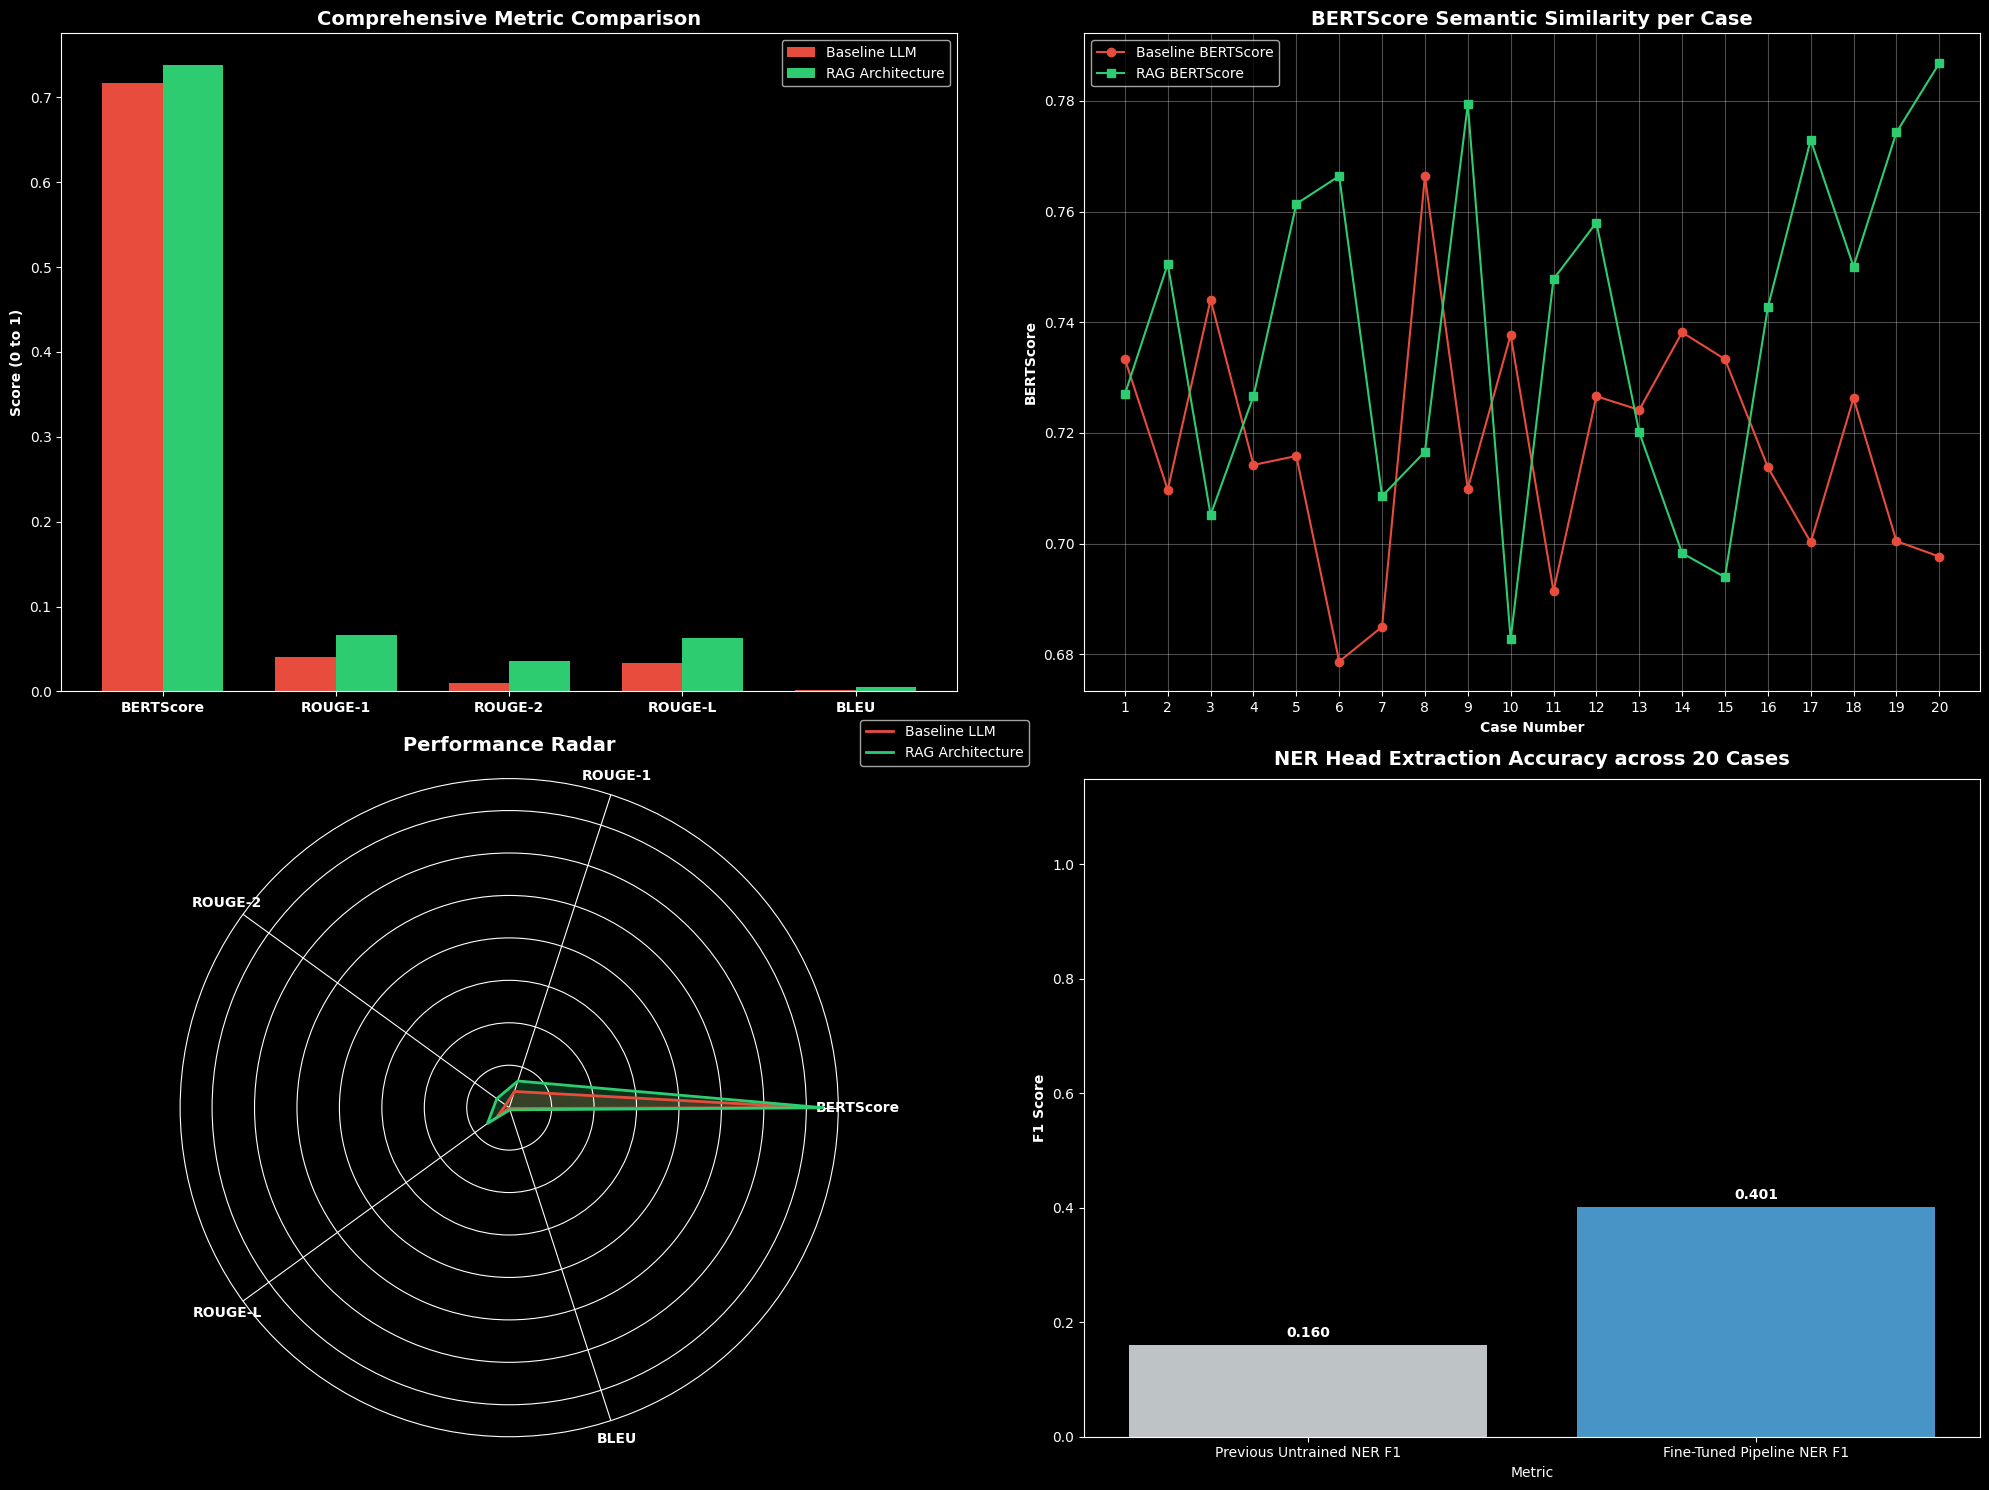

In [9]:
plt.style.use('dark_background')
fig = plt.figure(figsize=(20, 15))

ax1 = plt.subplot(2, 2, 1)
metrics_labels = ['BERTScore', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU']
base_means = [final_base_bert, np.mean(base_r1), np.mean(base_r2), np.mean(base_rl), np.mean(base_bleu)]
rag_means = [final_cag_bert, np.mean(cag_r1), np.mean(cag_r2), np.mean(cag_rl), np.mean(cag_bleu)]

x = np.arange(len(metrics_labels))
width = 0.35

ax1.bar(x - width/2, base_means, width, label='Baseline LLM', color='#e74c3c')
ax1.bar(x + width/2, rag_means, width, label='RAG Architecture', color='#2ecc71')
ax1.set_ylabel('Score (0 to 1)', fontweight='bold')
ax1.set_title('Comprehensive Metric Comparison', fontweight='bold', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_labels, fontweight='bold')
ax1.legend()

ax2 = plt.subplot(2, 2, 2)
case_numbers = np.arange(1, 21)
ax2.plot(case_numbers, Base_F1_list, marker='o', linestyle='-', color='#e74c3c', label='Baseline BERTScore')
ax2.plot(case_numbers, CAG_F1_list, marker='s', linestyle='-', color='#2ecc71', label='RAG BERTScore')
ax2.set_title('BERTScore Semantic Similarity per Case', fontweight='bold', fontsize=14)
ax2.set_xlabel('Case Number', fontweight='bold')
ax2.set_ylabel('BERTScore', fontweight='bold')
ax2.set_xticks(case_numbers)
ax2.grid(True, alpha=0.3)
ax2.legend()

ax3 = plt.subplot(2, 2, 3, polar=True)
angles = np.linspace(0, 2 * np.pi, len(metrics_labels), endpoint=False).tolist()
base_means_radar = base_means + [base_means[0]]
rag_means_radar = rag_means + [rag_means[0]]
angles += angles[:1]

ax3.plot(angles, base_means_radar, color='#e74c3c', linewidth=2, label='Baseline LLM')
ax3.fill(angles, base_means_radar, color='#e74c3c', alpha=0.25)
ax3.plot(angles, rag_means_radar, color='#2ecc71', linewidth=2, label='RAG Architecture')
ax3.fill(angles, rag_means_radar, color='#2ecc71', alpha=0.25)

ax3.set_yticklabels([])
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(metrics_labels, fontweight='bold')
ax3.set_title("Performance Radar", fontweight='bold', fontsize=14, pad=20)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

ax4 = plt.subplot(2, 2, 4)
ner_data = pd.DataFrame({
    'Metric': ['Previous Untrained NER F1', 'Fine-Tuned Pipeline NER F1'],
    'Score': [0.1597, np.mean(ner_f1s)] 
})
sns.barplot(data=ner_data, x='Metric', y='Score', palette=["#bdc3c7", "#3498db"], ax=ax4)
ax4.set_title("NER Head Extraction Accuracy across 20 Cases", fontsize=14, pad=10, fontweight='bold')
ax4.set_ylabel("F1 Score", fontweight='bold')
ax4.set_ylim(0, 1.15)
for p in ax4.patches:
    ax4.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontweight='bold', color='white')

plt.tight_layout()
plt.show()